DIAGNÓSTICO DE INTERMITENCIA: VITAMINA C+ZINC+D3
Total de semanas analizadas: 137
Semanas con 0 ventas absolutas: 3 (2.2%)


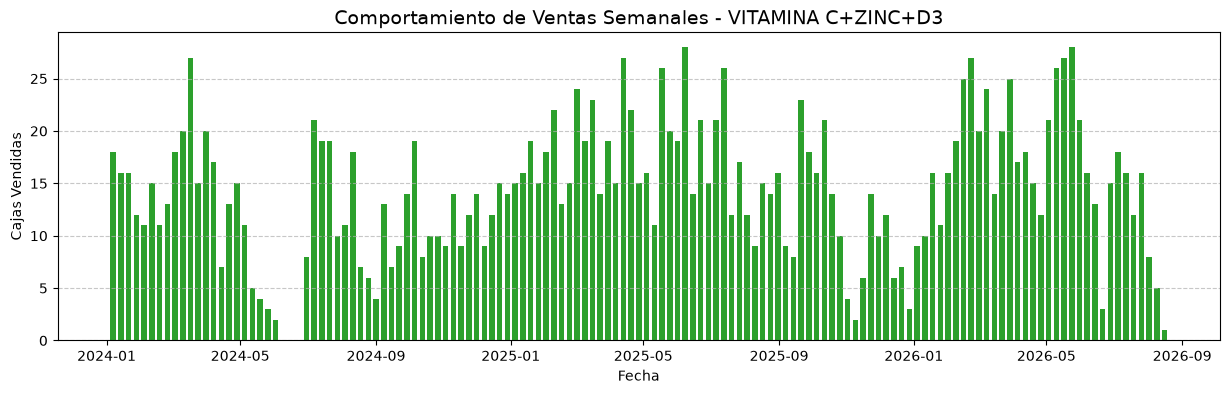

--------------------------------------------------
DIAGNÓSTICO DE INTERMITENCIA: ENALAPRIL 10MG
Total de semanas analizadas: 136
Semanas con 0 ventas absolutas: 17 (12.5%)


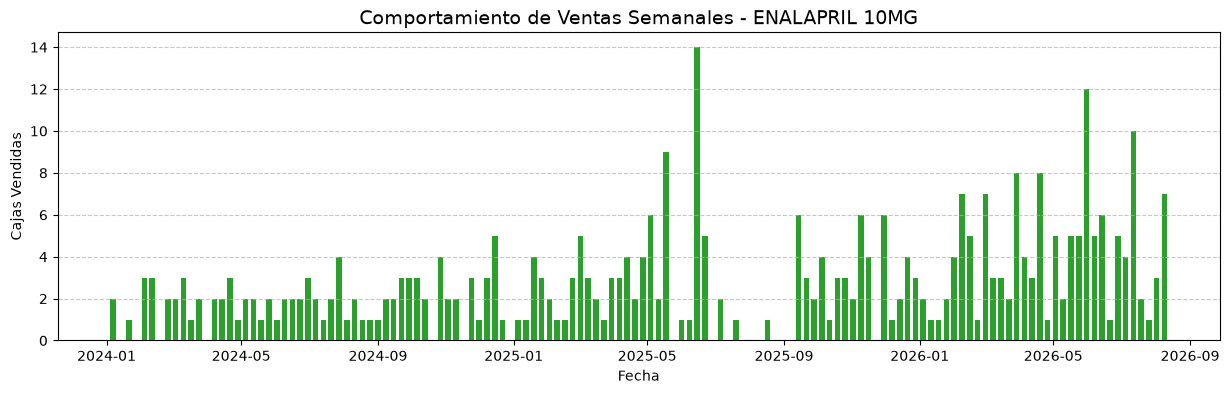

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# 1. Leer los datos nuevamente (Pipeline automático)
ruta_carpeta = "../datasets/final/" 
archivos = glob.glob(os.path.join(ruta_carpeta, "*_final.csv"))

lista_dfs = []
for archivo in archivos:
    df_temp = pd.read_csv(archivo)
    nombre_producto = os.path.basename(archivo).split('(')[0].replace('_final.csv', '').strip()
    df_temp['producto'] = nombre_producto
    lista_dfs.append(df_temp)

df_maestro = pd.concat(lista_dfs, ignore_index=True)
df_maestro['fecdoc'] = pd.to_datetime(df_maestro['fecdoc'])

# 2. Función para analizar la intermitencia de un producto
def analizar_intermitencia(producto_objetivo):
    # Filtrar solo el producto que queremos
    df_prod = df_maestro[df_maestro['producto'] == producto_objetivo]
    
    # Agrupar ventas por semana
    df_semanal = df_prod.set_index('fecdoc').resample('W')['cantidad'].sum().reset_index()
    
    # Rellenar semanas sin ventas con 0 explícitamente
    fechas_completas = pd.date_range(start=df_semanal['fecdoc'].min(), end=df_semanal['fecdoc'].max(), freq='W')
    df_semanal = df_semanal.set_index('fecdoc').reindex(fechas_completas, fill_value=0).reset_index()
    df_semanal.rename(columns={'index': 'fecdoc'}, inplace=True)
    
    # Calcular métricas clave
    total_semanas = len(df_semanal)
    semanas_cero = len(df_semanal[df_semanal['cantidad'] == 0])
    ceros_pct = (semanas_cero / total_semanas) * 100
    
    print(f"DIAGNÓSTICO DE INTERMITENCIA: {producto_objetivo}")
    print(f"Total de semanas analizadas: {total_semanas}")
    print(f"Semanas con 0 ventas absolutas: {semanas_cero} ({ceros_pct:.1f}%)")
    
    # Gráfico de barras (resalta los huecos en cero)
    plt.figure(figsize=(15, 4))
    plt.bar(df_semanal['fecdoc'], df_semanal['cantidad'], color='#2ca02c', width=5)
    plt.title(f'Comportamiento de Ventas Semanales - {producto_objetivo}', fontsize=14)
    plt.ylabel('Cajas Vendidas')
    plt.xlabel('Fecha')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# 3. Analizar nuestros dos productos estrella
analizar_intermitencia('VITAMINA C+ZINC+D3')
print("-" * 50)
analizar_intermitencia('ENALAPRIL 10MG')